In [1]:
import numpy as np
import qutip as qt
from Quantum_dot_2qubit import *
from tqdm import tqdm
import pickle
from entropy import RDM_entropy, von_neumann_entropy
from qiskit.quantum_info import Statevector, partial_trace
import random as rand

N=12
d=2**N

exact_model = Quantum_dot(np.pi/1e9)
analog_model = analog_QD(exact_model, h=5e5,J=1e6, DeltaE=2e8,epsilon=0.01) #theta represents tan(theta) in the paper


def computation_basis_state(num_qubits):
    #retrun a list of all computational basis states for num_qubits qubits, represented as integers lists
    basis_states = []
    for i in range(2**num_qubits):
        bin_str = format(i, '0' + str(num_qubits) + 'b')
        basis_states.append([int(bit) for bit in bin_str])
    return basis_states

def thermal_state(temperature):
    basis = computation_basis_state(4)
    computation_basis = [basis[i]+basis[i] for i in range(len(basis))]
    H=qt.Qobj(np.zeros((d,d)), dims=[[2]*N]*2)
    for i in range(4,N):
        H-=qt.tensor([qt.sigmaz() if j == i else qt.qeye(2) for j in range(N)])
    # psi_T = qt.Qobj(np.zeros(d), dims=[2]*N)
    psi_T = qt.Qobj(np.zeros((d,1)), dims=[[2]*N, [1]])
    for A_subsys in computation_basis:
        psi_T += qt.tensor(qt.basis([2]*4),qt.basis([2]*8,A_subsys))
    # Calculate the thermal state using the Gibbs distribution
    psi_T = (-H * temperature).expm()*psi_T

    # unitary = qt.tensor(
    #     qt.sigmax() if i == 0 or i==1 else qt.qeye(2) for i in range(N)
    # )
    # for j in range(1,7):
    #     unitary += qt.tensor(
    #         qt.sigmax() if i == j or i==j+1 else qt.qeye(2) for i in range(N)
    #     )
    # psi_T = unitary * psi_T
    return psi_T.unit()

def analog_error(initial_state, analog_model : analog_QD,time):
    # Compute the error between the initial state and the analog model
    exact_states=qt.mesolve(analog_model.exact_model.H,initial_state, time).states
    analog_states=qt.mesolve(analog_model.H,initial_state, time).states
    errors = [exact_states[i]-analog_states[i] for i in range(len(time))]
    error_norms = [err.norm('l2') for err in errors]
    return error_norms

seed=123

entropy_list = []
error_list = []
# initial_state = qt.rand_ket([2]*10,seed = 123)
# initial_state = qt.basis([2]*10)
for temperature in tqdm(range(60)):
    state = thermal_state((temperature)*0.008)
    rho=partial_trace(Statevector(state.full()),range(4,12))
    entropy_list.append(von_neumann_entropy(rho))
    error_list.append(analog_error(state,analog_model,np.linspace(0,1e-7 , 5)))

100%|██████████| 60/60 [00:46<00:00,  1.29it/s]


In [2]:
bound=[]
perturbation=analog_model.H-exact_model.H
for i in range(4):
    bound.append(2.5e-8*(i+1)*np.linalg.norm(perturbation.full(),'fro')/sqrt(d))
        # summator+=5e-11*np.linalg.norm(perturbation(2.5e-8*i+5e-11*j).full(),'fro')**2/d

/tmp/ipykernel_37897/3214305320.py:3: RuntimeWarning: invalid value encountered in power
  return a*np.power(2.01-t,0.25)+b
/tmp/ipykernel_37897/3214305320.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[0], p0=[0.01, 0.01])
/tmp/ipykernel_37897/3214305320.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[1], p0=[0.01, 0.01])
/tmp/ipykernel_37897/3214305320.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[2], p0=[0.01, 0.01])
/tmp/ipykernel_37897/3214305320.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[3], p0=[0.01, 0.01])


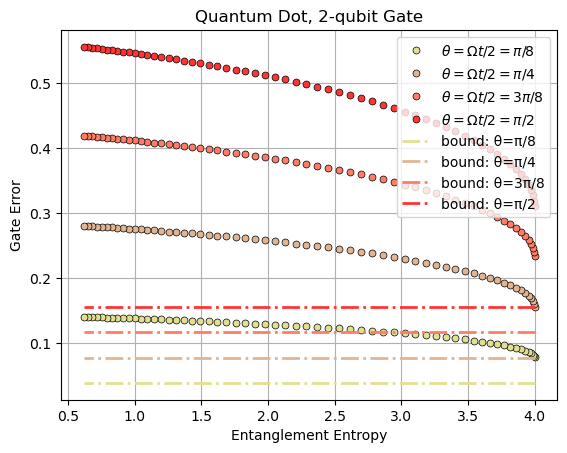

In [3]:
from scipy.optimize import curve_fit
def error_vs_entropy(t,a,b):
    return a*np.power(2.01-t,0.25)+b
error_plot_list=[]
for i in range(4):
    error_plot_list.append(np.array(error_list)[:,i+1])
fit_line1 = []
popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[0], p0=[0.01, 0.01])
fit_line1 = error_vs_entropy(np.array(entropy_list), *popt)

fit_line2 = []
popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[1], p0=[0.01, 0.01])
fit_line2 = error_vs_entropy(np.array(entropy_list), *popt)

fit_line3 = []
popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[2], p0=[0.01, 0.01])
fit_line3 = error_vs_entropy(np.array(entropy_list), *popt)

fit_line4 = []
popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[3], p0=[0.01, 0.01])
fit_line4 = error_vs_entropy(np.array(entropy_list), *popt)

import matplotlib.pyplot as plt
plt.plot(entropy_list,np.array(error_list)[:,1],color='0.3', marker='o', markersize=5, mfc="#e1e092", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=\pi/8$')
plt.plot(entropy_list,np.array(error_list)[:,2],color='0.3', marker='o', markersize=5, mfc="#e1b592", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=\pi/4$')
plt.plot(entropy_list,np.array(error_list)[:,3],color='0.3', marker='o', markersize=5, mfc="#ff7c67", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=3\pi/8$')
plt.plot(entropy_list,np.array(error_list)[:,4],color='0.3', marker='o', markersize=5, mfc="#ff3434", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=\pi/2$')
# plt.plot(entropy_list,fit_line1,color="#82c5c7", linestyle='--', label='fit: θ=π/8',linewidth=2)
# plt.plot(entropy_list,fit_line2,color="#88be7d", linestyle='--', label='fit: θ=π/4',linewidth=2)
# plt.plot(entropy_list,fit_line3,color="#b8a978", linestyle='--', label='fit: θ=3π/8',linewidth=2)
# plt.plot(entropy_list,fit_line4,color="#be7d7d", linestyle='--', label='fit: θ=π/2',linewidth=2)
plt.plot(entropy_list,[bound[0]]*60,color='#e1e092', linestyle='-.', label='bound: θ=π/8',linewidth=2)
plt.plot(entropy_list,[bound[1]]*60,color='#e1b592', linestyle='-.', label='bound: θ=π/4',linewidth=2)
plt.plot(entropy_list,[bound[2]]*60,color='#ff7c67', linestyle='-.', label='bound: θ=3π/8',linewidth=2)
plt.plot(entropy_list,[bound[3]]*60,color="#ff3434", linestyle='-.', label='bound: θ=π/2',linewidth=2)
plt.xlabel('Entanglement Entropy')
plt.ylabel('Gate Error')
plt.title('Quantum Dot, 2-qubit Gate')
plt.legend(loc=1)
plt.grid()
plt.savefig('./Figures/QD_2qubits.pdf',bbox_inches='tight',dpi=600)
plt.show()